# Factor-Based Portfolio Optimisation

This project is a collaboration between:
- **Amelia Yamato Leow Mei Li**
- **Kevin Tan YueJun**

In this notebook, we develop and evaluate a factor-driven portfolio optimisation framework applied to a universe of **SGX-listed securities**. Our primary objective is to construct a diversified portfolio that maximises the **Sharpe Ratio**, balancing expected return against total risk. The workflow is structured as follows:

---

**Section 1: Import Libraries and Dependencies**

> Setup of all required Python libraries and supporting modules.

**Section 2: Data Acquisition (YFinance API)**

Collection and preparation of historical market data.

> **2.1 Parameter Initialisation**  
> Definition of asset universe, time horizon, and optimisation parameters.  
>
> **2.2 Historical Data Collection**  
> Retrieval and preprocessing of price data.

**Section 3: Portfolio Optimisation (PyPortfolioOpt)**

Implementation of modern portfolio theory techniques.

> **3.1 Mean-Variance Optimisation (MVO)**  
> Estimation of expected returns and covariance matrix, followed by Sharpe ratio maximisation.  
>
> **3.2 Portfolio Performance under MVO**  
> Evaluation of expected return, volatility, and Sharpe ratio.

**Section 4: Backtesting Framework**

Assessment of realised performance using historical data.

> **4.1 Approach A: Log Return-Based Backtest**  
> Performance computation using continuously compounded returns.  
>
> **4.2 Approach B: Discrete Allocation & Portfolio Valuation**  
> Simulation of capital allocation and portfolio value over time.

**Section 5: Sector-Constrained Optimisation**

Exploration of allocation strategies under different portfolio objectives.

> **5.1 Experiment 1: Fully Diversified Portfolio**  
> Broad exposure across sectors.  
>
> **5.2 Experiment 2: Growth-Oriented Portfolio**  
> Tilt towards higher expected return sectors.  
>
> **5.3 Experiment 3: Defensive Portfolio**  
> Allocation focused on stability and downside protection.

**Section 6: Portfolio Performance Evaluation**

Comparative analysis against benchmark performance.

> **6.1 Benchmark Metrics**  
> Risk-adjusted and absolute performance statistics.  
>
> **6.2 Performance Visualisation**  
> Portfolio returns plotted against benchmark performance.

#### Section 1: Import Libraries and Dependencies

In [77]:
#!pip install PyPortfolioOpt

**Import the necessary libraries**

In [111]:
import pandas as pd
import numpy as np
import yfinance as yf
import math
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import linregress
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

# Suppress FutureWarning globally
warnings.simplefilter(action='ignore', category=FutureWarning)

#### Section 2: Yfinance Data (API)

Over here, we will initialise our parameters for the analysis

**Section 2.1: Parameter Initialisation**

In [79]:
stocks = [
  'D05.SI',   # DBS Group Holdings Ltd.
  'O39.SI',   # Oversea-Chinese Banking Corp Limited
  'U11.SI',   # United Overseas Bank Limited
  'C38U.SI',  # CapitaLand Integrated Commercial Trust
  'C6L.SI',   # Singapore Airlines Limited
  'S63.SI',   # ST Engineering
  'F34.SI',   # Wilmar International Limited
  'A17U.SI',  # Ascendas Real Estate Investment Trust
  'Z74.SI',   # Singapore Telecommunications Limited
  'BN4.SI',   # Keppel Corporation Limited
  'G13.SI',   # Genting Singapore PLC
  'C52.SI',   # ComfortDelgro Corporation Limited
  'BS6.SI',   # Yangzijiang Shipbuilding (Holdings) Ltd
  'S68.SI',   # Singapore Exchange Limited
  'Y92.SI',   # Thai Beverage Public Co Ltd
  'C09.SI'    # City Developments Limited
]
portfolio_value = 1000000
train_start = '2015-01-01' # Train
train_end = '2022-12-31' # Train
backtesting_start = '2023-01-01' # Test
backtesting_end = '2023-11-01' # Test
benchmark = 'ES3.SI' # Benchmark for portfolio evaluation

#### Section 2.2: Historical Data Collection

In [80]:
def closing_price_dataframe(stocks, start, end):
  stock_df = pd.DataFrame()
  for stock in stocks:
    try:
      # Close column in yf.Ticker function corresponds to adjusted closing price in yf.download function
      stock_df[f'{stock}'] = yf.Ticker(stock).history(start=start, end=end).Close
    except:
      print(f'{stock} was not found')

  # Handle the datetime index
  stock_df.index = stock_df.index.strftime('%Y-%m-%d')
  return stock_df

In [81]:
stocks_data = closing_price_dataframe(stocks, train_start, train_end)

### Section 3: Portfolio Optimisation with PyPortfolioOpt

In this section, we estimate the key inputs required for portfolio optimisation — namely the **expected returns (mean vector)** and the **covariance matrix** of asset returns.

These parameters form the foundation of the mean-variance optimisation framework. While the sample covariance matrix can be computed directly using the standard `cov()` method, it is often unstable and noisy when dealing with high-dimensional financial data. This instability can lead to extreme or unintuitive portfolio weights during optimisation.

To address this issue, we apply the **Ledoit-Wolf shrinkage estimator**, which improves covariance estimation by shrinking the sample covariance matrix toward a structured target matrix. This approach reduces estimation error, enhances numerical stability, and produces more robust portfolio allocations.

In [82]:
# Deriving the mean
mean = mean_historical_return(stocks_data)

# Deriving the covariance
cov = CovarianceShrinkage(stocks_data).ledoit_wolf()

#### Section 3.1: Mean-Variance Optimisation (MVO)

In this section, we implement **Mean-Variance Optimisation (MVO)** using the `EfficientFrontier` class from the PyPortfolioOpt library. The objective is to determine the portfolio weights that maximise the **Sharpe Ratio**, thereby achieving the highest risk-adjusted return.

Mean-Variance Optimisation, introduced by Harry Markowitz, relies on two key inputs:

- **Expected returns vector (μ)** — the estimated return of each asset.
- **Covariance matrix (Σ)** — representing asset volatilities and their co-movements.

The Sharpe ratio maximisation problem can be written as:

$$
\max_w \quad \frac{w^T \mu - r_f}{\sqrt{w^T \Sigma w}}
$$

subject to:

$$
\sum_{i=1}^{n} w_i = 1
$$

and additional constraints such as long-only positions:

$$
w_i \ge 0
$$

Where:
- $w$ is the vector of portfolio weights,
- $\mu$ is the expected return vector,
- $\Sigma$ is the covariance matrix,
- $r_f$ is the risk-free rate.

---

### Implementation

We begin by constructing the efficient frontier object and solving for the maximum Sharpe ratio portfolio:

```python
print('Running Portfolio Optimisation Process')
eff_front = EfficientFrontier(mean, cov)
weights = eff_front.max_sharpe()

In [83]:
print('Running Portfolio Optimisation Process')
eff_front = EfficientFrontier(mean, cov)

weights = eff_front.max_sharpe()
cleaned_weights = eff_front.clean_weights()

# Append the data into a pandas dataframe for better visualization
result = pd.DataFrame({
  'Weights': list(weights.values()),
  'Cleaned Weight': list(cleaned_weights.values())
}, columns=['Weights', 'Cleaned Weight'])
result.index = list(weights.keys())
result

Running Portfolio Optimisation Process


,Weights,Cleaned Weight
D05.SI,0.220446,0.22045
O39.SI,0.000000,0.00000
U11.SI,0.021642,0.02164
C38U.SI,0.000000,0.00000
C6L.SI,0.000000,0.00000
S63.SI,0.000000,0.00000
F34.SI,0.027560,0.02756
A17U.SI,0.131696,0.13170
Z74.SI,0.000000,0.00000
BN4.SI,0.000000,0.00000


#### Section 3.2 Portfolio Performance using MVO

In [84]:
print("Portfolio Performance:\n")
eff_front.portfolio_performance(verbose=True)

Portfolio Performance:

Expected annual return: 52.1%
Annual volatility: 33.3%
Sharpe Ratio: 1.57


(0.5210035023631712, 0.33254956810780195, 1.5666942685496992)

### Section 4: Backtesting

*Period: 2023 - Current Date*

Backtesting is a critical step in evaluating the performance and robustness of a trading strategy using historical data. In this section, we examine how the strategy would have performed over the defined period, from 2023 to the present. By simulating trades on historical stock prices, we can estimate potential returns, risk, and other key performance metrics before deploying the strategy in a live environment.

#### Section 4.1: Approach A (Log Return Calculation)

For Approach A, we focus on calculating the daily log returns of the selected stocks. Log returns are preferred in many quantitative finance applications because they allow for easy aggregation over time and assume a continuous compounding framework, which aligns well with many portfolio and risk models.

In [85]:
backtesting_data = closing_price_dataframe(stocks, backtesting_start, backtesting_end)

# Derive the daily log returns
backtesting_reg_returns = pd.DataFrame()
for stock in list(backtesting_data.columns):
  backtesting_reg_returns[stock] = backtesting_data[stock].pct_change()
backtesting_reg_returns = backtesting_reg_returns.dropna()
backtesting_reg_returns.head()

,D05.SI,O39.SI,U11.SI,C38U.SI,C6L.SI,S63.SI,F34.SI,A17U.SI,Z74.SI,BN4.SI,G13.SI,C52.SI,BS6.SI,S68.SI,Y92.SI,C09.SI
Date,,,,,,,,,,,,,,,,
2023-01-04,0.004132,0.004085,-0.007818,-0.009852,-0.001821,0.000000,-0.004866,0.003649,-0.007843,-0.006878,-0.010526,0.008130,-0.062500,-0.007892,-0.007353,-0.023284
2023-01-05,0.022340,0.012205,0.016743,0.014925,0.010949,0.011870,0.009780,0.014546,-0.003953,0.013850,0.021277,-0.008064,-0.016667,0.012500,0.022222,0.006274
2023-01-06,-0.008913,0.004823,-0.004198,-0.019608,-0.001805,-0.008798,0.002421,-0.021505,0.003968,-0.008197,0.010417,0.000000,0.042373,-0.001122,0.000000,-0.028678
2023-01-09,0.022628,0.016000,-0.005512,0.010000,0.007233,0.014793,0.007246,0.014652,-0.007905,0.006887,0.000000,0.000000,-0.016260,0.016854,0.028986,-0.005135
2023-01-10,-0.019575,-0.012598,-0.018585,-0.009901,0.001795,-0.005831,-0.009592,-0.014440,-0.015936,-0.005472,0.010309,0.000000,-0.024793,-0.008840,-0.007042,-0.009032


**Portfolio Metrics**

After calculating individual stock returns, the next step is to evaluate the performance of the constructed portfolio. This involves computing aggregate portfolio returns, volatility, and risk-adjusted measures like the Sharpe ratio.

In [86]:
def portfolio_metrics(dataframe):
  df = dataframe.copy()

  # Total Portfolio Return (regular and log)
  annual_log_return = df['portfolio_log_returns'].mean() * 252
  annual_regular_return = (np.exp(annual_log_return) - 1)

  print('Portfolio Annual Log Return: ', annual_log_return)
  print('Portfolio Annual Regular Return: ', annual_regular_return)

  # Standard Deviation
  daily_regular_std = (np.exp(df['portfolio_log_returns']) - 1).std()
  annual_regular_std = daily_regular_std * np.sqrt(252)

  print('Daily Standard Deviation: ', daily_regular_std)
  print('Annual Standard Deviation: ', annual_regular_std)

  # Sharpe Ratio
  sharpe_ratio = annual_regular_return / annual_regular_std if annual_regular_std != 0 else 0
  print('Sharpe Ratio: ', sharpe_ratio)
  return annual_log_return, annual_regular_return, daily_regular_std, annual_regular_std, sharpe_ratio

In [87]:
backtesting_reg_returns['portfolio_reg_returns'] = backtesting_reg_returns.dot(list(cleaned_weights.values()))
backtesting_reg_returns['portfolio_log_returns'] = np.log(backtesting_reg_returns['portfolio_reg_returns'] + 1)
a_annual_log_return, a_annual_regular_return, a_daily_regular_std, a_annual_regular_std, a_sharpe_ratio = portfolio_metrics(backtesting_reg_returns)

Portfolio Annual Log Return:  0.6155970131540262
Portfolio Annual Regular Return:  0.8507611985759576
Daily Standard Deviation:  0.037270313761612356
Annual Standard Deviation:  0.5916478889914473
Sharpe Ratio:  1.437951887272357


In [88]:
# To pass into the performance comparison function at the last part
approach_a_portfolio_metrics = {
  'total_log_returns': a_annual_log_return,
  'total_regular_returns': a_annual_regular_return,
  'daily_regular_std': a_daily_regular_std,
  'sharpe_ratio': a_sharpe_ratio
}

#### Section 4.2: Approach B (Discrete Allocation and Portfolio Valuation)

In Approach B, we move beyond calculating portfolio returns purely in percentage terms and instead focus on actual portfolio valuation by determining the number of shares to purchase for each stock based on target weights. This approach is closer to a real-world implementation of a portfolio because it accounts for discrete shares and investment capital limitations.

**Identifying number of shares to purchase from the weights using the train data**

We then use the DiscreteAllocation class to compute the optimal number of shares for each stock

In [89]:
latest_prices = get_latest_prices(stocks_data)
discrete_allocation = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=portfolio_value)
allocation, leftover = discrete_allocation.lp_portfolio()

# Save the allocation as base_portfolio for use in subsequent computation
base_portfolio = allocation

# Redefine stock quantity dictionary
stock_qty = []
for stock in stocks:
  if stock in allocation.keys():
    stock_qty.append(allocation[stock])
  else:
    stock_qty.append(0)

print("LP Portfolio Allocation: ", allocation)
print("Stock Quantity Allocation: ", stock_qty)
print("Total Capital Used: $", np.dot(list(latest_prices), stock_qty))
print("Leftover amount after share purchase: $", leftover)

LP Portfolio Allocation:  {'D05.SI': 8724, 'O39.SI': 859, 'U11.SI': 933, 'C38U.SI': 10116, 'C6L.SI': 2204, 'S63.SI': 3913, 'F34.SI': 9524, 'A17U.SI': 62453, 'Z74.SI': 6104, 'BN4.SI': 2676, 'G13.SI': 49902, 'C52.SI': 27199, 'BS6.SI': 277846, 'S68.SI': 7832, 'Y92.SI': 8388608, 'C09.SI': 1185}
Stock Quantity Allocation:  [8724, 859, 933, 10116, 2204, 3913, 9524, 62453, 6104, 2676, 49902, 27199, 277846, 7832, 8388608, 1185]
Total Capital Used: $ 996719.3508147001
Leftover amount after share purchase: $ 3280.64919084101


**Backtesting on test data**

In [90]:
backtesting_data = closing_price_dataframe(stocks, backtesting_start, backtesting_end)

# Portfolio Value
test_df = backtesting_data.copy()
test_df['Portfolio Value'] = test_df.dot(stock_qty)
test_df['portfolio_log_returns'] = np.log(test_df['Portfolio Value'] / test_df['Portfolio Value'].shift(1))
test_df = test_df.dropna()
test_df.head()

,D05.SI,O39.SI,U11.SI,C38U.SI,C6L.SI,S63.SI,F34.SI,A17U.SI,Z74.SI,BN4.SI,G13.SI,C52.SI,BS6.SI,S68.SI,Y92.SI,C09.SI,Portfolio Value,portfolio_log_returns
Date,,,,,,,,,,,,,,,,,,
2023-01-04,25.635752,10.226060,25.532221,1.673797,4.563818,3.044619,3.548808,2.260005,2.238627,3.945379,0.820534,1.053805,1.049468,7.963449,0.003425,7.483884,955492.396716,-0.020527
2023-01-05,26.208450,10.350866,25.959713,1.698779,4.613786,3.080757,3.583515,2.292878,2.229778,4.000023,0.837992,1.045307,1.031977,8.062989,0.003501,7.530835,961228.655405,0.005986
2023-01-06,25.974850,10.400792,25.850744,1.665470,4.605458,3.053654,3.592192,2.243569,2.238627,3.967236,0.846721,1.045307,1.075705,8.053941,0.003501,7.314862,967898.407615,0.006915
2023-01-09,26.562620,10.567204,25.708250,1.682124,4.638771,3.098826,3.618222,2.276441,2.220930,3.994558,0.846721,1.045307,1.058213,8.189684,0.003603,7.277303,972730.943037,0.004980
2023-01-10,26.042669,10.434074,25.230461,1.665470,4.647099,3.080757,3.583515,2.243569,2.185537,3.972701,0.855450,1.045307,1.031977,8.117287,0.003578,7.211571,957043.911237,-0.016258


In [91]:

b_annual_log_return, b_annual_regular_return, b_daily_regular_std, b_annual_regular_std, b_sharpe_ratio = portfolio_metrics(test_df)

Portfolio Annual Log Return:  0.14831367075172025
Portfolio Annual Regular Return:  0.15987665869262457
Daily Standard Deviation:  0.008661435355993561
Annual Standard Deviation:  0.137496023692927
Sharpe Ratio:  1.1627729617089202


In [92]:
approach_b_portfolio_metrics = {
  'total_log_returns': b_annual_log_return,
  'total_regular_returns': b_annual_regular_return,
  'daily_regular_std': b_annual_regular_std,
  'sharpe_ratio': b_sharpe_ratio
}

### Section 5: Sector Constraints

The following dictionary maps each of our selected stock to their respective industry / sector. This would be useful in the subsequent code blocks when we introduce a series of sector constraints to our overall portfolio optimisation process

In [93]:
sector_mapper = {
  "D05.SI": "Finance",
  "O39.SI": "Finance",
  "U11.SI": "Finance",
  "C38U.SI": "Real Estate",
  "C6L.SI": "Transportation",
  "S63.SI": "Technology & Engineering",
  "F34.SI": "Consumer Goods & Services",
  "A17U.SI": "Real Estate",
  "Z74.SI": "Technology & Engineering",
  "BN4.SI": "Industrial & Manufacturing",
  "G13.SI": "Consumer Goods & Services",
  "C52.SI": "Transportation",
  "BS6.SI": "Industrial & Manufacturing",
  "S68.SI": "Finance",
  "Y92.SI": "Consumer Goods & Services",
  "C09.SI": "Real Estate"
}

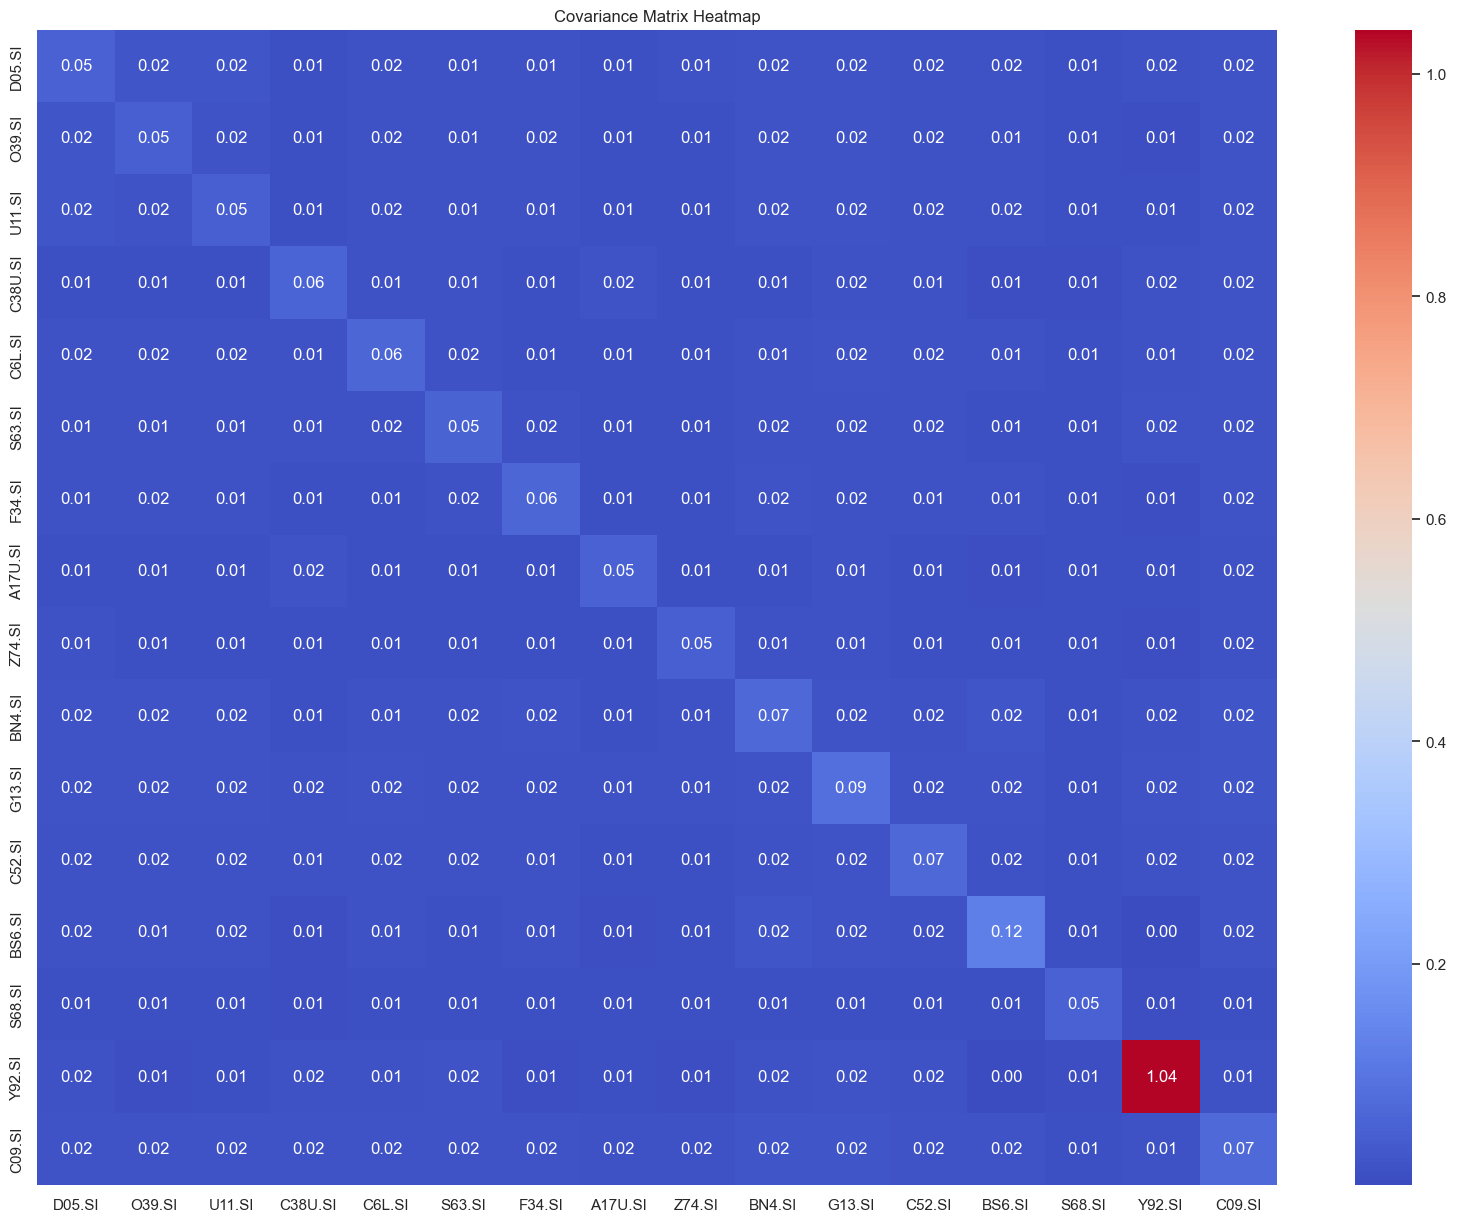

In [99]:
# Visualise our covariance matrix in the form of a heat map for all of our chosen stocks
sns.set(style="white")  # Set the background style
# Create a heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(cov, annot=True, cmap="coolwarm", fmt=".2f", xticklabels=list(sector_mapper.keys()), yticklabels=list(sector_mapper.keys()))
plt.title('Covariance Matrix Heatmap')
plt.show()

Let us create a dictionary to store our portfolio allocation for all 3 sector variations

In [101]:
portfolios = {}

#### Section 5.1: (Experiment 1) Fully Diversified Portfolio

For our fully diversified portfolio, we do not prescribe a bandwidth within which our sector portfolio allocation should fall for our portfolio. In other words, our sector upper and lower will take on the following values irregardless of our sector of focus:

> Sector Lower: 0 (At least 0% of capital to the sector of interest)

> Sector Upper: 1.0 (Less than 100% of capital to the sector of interest)

Unfeasible solution (Tighter Constraints)

In [102]:
sector_lower = {
  "Finance": 0.01,
  "Real Estate": 0.01,
  "Transportation": 0.01,
  "Technology & Engineering": 0.01,
  "Industrial & Manufacturing": 0.01,
  "Consumer Goods & Services": 0.01,
  "Investment & Holdings": 0.01
}

sector_upper = {
  "Finance": 0.5,
  "Real Estate": 0.5,
  "Transportation": 0.5,
  "Technology & Engineering": 0.5,
  "Industrial & Manufacturing": 0.5,
  "Consumer Goods & Services": 0.5,
  "Investment & Holdings": 0.5
}

# Optimize for the maximal Sharpe ratio
ef = EfficientFrontier(mean, cov) # Using the mean and covariance of our stocks during the backtesting period
ef.add_sector_constraints(sector_mapper, sector_lower, sector_upper) # Adding the sector constraint to our ef object
try:
  raw_weights = ef.max_sharpe()
  cleaned_weights = ef.clean_weights()
  performance_metrics = ef.portfolio_performance(verbose=True)

  # Extract individual metrics
  expected_annual_return, annual_volatility, sharpe_ratio = performance_metrics
  expected_annual_return = expected_annual_return
  annual_volatility = annual_volatility

  annual_regular_return_decimal = expected_annual_return
  annual_log_return = np.log(1 + annual_regular_return_decimal)
  annual_log_return = annual_log_return

  diversified_portfolio_metrics = {
    'annual_log_returns': annual_log_return,
    'annual_regular_returns': expected_annual_return,
    'annual_regular_std': annual_volatility,
    'sharpe_ratio': sharpe_ratio
  }

  # Calculate the discrete allocation of each share
  latest_prices = stocks_data.iloc[-1]
  da = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=portfolio_value)
  allocation, leftover = da.lp_portfolio()
  print(f"Discrete allocation performed with ${leftover:.2f} leftover")
  print(allocation)
  print("\nDiversified Portfolio Metics: \n", diversified_portfolio_metrics)
  portfolios['Diversified Portfolio'] = allocation
except Exception as e:
    print("Optimization error:", e)

Optimization error: ('Please check your objectives/constraints or use a different solver.', 'Solver status: infeasible')


Unfeasible Solution (Looser Constraints)

In [103]:
sector_lower = {
  "Finance": 0.01,
  "Real Estate": 0.01,
  "Transportation": 0.01,
  "Technology & Engineering": 0.01,
  "Industrial & Manufacturing": 0.01,
  "Consumer Goods & Services": 0.01,
  "Investment & Holdings": 0.01
}

sector_upper = {
  "Finance": 0.99,
  "Real Estate": 0.99,
  "Transportation": 0.99,
  "Technology & Engineering": 0.99,
  "Industrial & Manufacturing": 0.99,
  "Consumer Goods & Services": 0.99,
  "Investment & Holdings": 0.99
}

# Optimize for the maximal Sharpe ratio
ef = EfficientFrontier(mean, cov) # Using the mean and covariance of our stocks during the backtesting period
ef.add_sector_constraints(sector_mapper, sector_lower, sector_upper) # Adding the sector constraint to our ef object
try:
  raw_weights = ef.max_sharpe()
  cleaned_weights = ef.clean_weights()
  performance_metrics = ef.portfolio_performance(verbose=True)

  # Extract individual metrics
  expected_annual_return, annual_volatility, sharpe_ratio = performance_metrics
  expected_annual_return = expected_annual_return
  annual_volatility = annual_volatility

  annual_regular_return_decimal = expected_annual_return
  annual_log_return = np.log(1 + annual_regular_return_decimal)
  annual_log_return = annual_log_return

  diversified_portfolio_metrics = {
    'annual_log_returns': annual_log_return,
    'annual_regular_returns': expected_annual_return,
    'annual_regular_std': annual_volatility,
    'sharpe_ratio': sharpe_ratio
  }

  # Calculate the discrete allocation of each share
  latest_prices = stocks_data.iloc[-1]
  da = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=portfolio_value)
  allocation, leftover = da.lp_portfolio()
  print(f"Discrete allocation performed with ${leftover:.2f} leftover")
  print(allocation)
  print("\nDiversified Portfolio Metics: \n", diversified_portfolio_metrics)
  portfolios['Diversified Portfolio'] = allocation
except Exception as e:
    print("Optimization error:", e)

Optimization error: ('Please check your objectives/constraints or use a different solver.', 'Solver status: infeasible')


Feasible Solution with loose constraints

In [ ]:
sector_lower = {
  "Finance": 0.0,
  "Real Estate": 0.0,
  "Transportation": 0.0,
  "Technology & Engineering": 0.0,
  "Industrial & Manufacturing": 0.0,
  "Consumer Goods & Services": 0.0,
  "Investment & Holdings": 0.0
}

sector_upper = {
  "Finance": 1.0,
  "Real Estate": 1.0,
  "Transportation": 1.0,
  "Technology & Engineering": 1.0,
  "Industrial & Manufacturing": 1.0,
  "Consumer Goods & Services": 1.0,
  "Investment & Holdings": 1.0
}

# Optimize for the maximal Sharpe ratio
ef = EfficientFrontier(mean, cov) # Using the mean and covariance of our stocks during the backtesting period
ef.add_sector_constraints(sector_mapper, sector_lower, sector_upper) # Adding the sector constraint to our ef object
try:
  raw_weights = ef.max_sharpe()
  cleaned_weights = ef.clean_weights()
  performance_metrics = ef.portfolio_performance(verbose=True)

  # Extract individual metrics
  expected_annual_return, annual_volatility, sharpe_ratio = performance_metrics
  expected_annual_return = expected_annual_return
  annual_volatility = annual_volatility

  annual_regular_return_decimal = expected_annual_return
  annual_log_return = np.log(1 + annual_regular_return_decimal)
  annual_log_return = annual_log_return

  diversified_portfolio_metrics = {
    'annual_log_returns': annual_log_return,
    'annual_regular_returns': expected_annual_return,
    'annual_regular_std': annual_volatility,
    'sharpe_ratio': sharpe_ratio
  }

  # Calculate the discrete allocation of each share
  latest_prices = stocks_data.iloc[-1]
  da = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=portfolio_value)
  allocation, leftover = da.lp_portfolio()
  print(f"Discrete allocation performed with ${leftover:.2f} leftover")
  print(allocation)
  print("\nDiversified Portfolio Metics: \n", diversified_portfolio_metrics)
  portfolios['Diversified Portfolio'] = allocation
except Exception as e:
  print("Optimization error:", e)

Expected annual return: 52.1%
Annual volatility: 33.3%
Sharpe Ratio: 1.57
Discrete allocation performed with $3280.65 leftover
{'D05.SI': 8724, 'O39.SI': 859, 'U11.SI': 933, 'C38U.SI': 10116, 'C6L.SI': 2204, 'S63.SI': 3913, 'F34.SI': 9524, 'A17U.SI': 62453, 'Z74.SI': 6104, 'BN4.SI': 2676, 'G13.SI': 49902, 'C52.SI': 27199, 'BS6.SI': 277846, 'S68.SI': 7832, 'Y92.SI': 8388608, 'C09.SI': 1185}

Diversified Portfolio Metics: 
 {'annual_log_returns': 0.4193703159458861, 'annual_regular_returns': 0.5210035023631712, 'annual_regular_std': 0.332549568107802, 'sharpe_ratio': 1.566694268549699}


#### Section 5.3: (Experiment 2) Growth-Oriented Portfolio

In [ ]:
sector_lower = {
  "Finance": 0.0,
  "Real Estate": 0.05,
  "Transportation": 0.35,
  "Technology & Engineering": 0.05,
  "Industrial & Manufacturing": 0.05,
  "Consumer Goods & Services": 0.35,
  "Investment & Holdings": 0.0
}

sector_upper = {
  "Finance": 1.0,
  "Real Estate": 0.7,
  "Transportation": 1.0,
  "Technology & Engineering": 1.0,
  "Industrial & Manufacturing": 0.8,
  "Consumer Goods & Services": 0.6,
  "Investment & Holdings": 0.6
}

ef = EfficientFrontier(mean, cov)
ef.add_sector_constraints(sector_mapper, sector_lower, sector_upper)
try:
  raw_weights = ef.max_sharpe()
  cleaned_weights = ef.clean_weights()
  ef.portfolio_performance(verbose=True)

  # Calculate the discrete allocation of each share
  latest_prices = stocks_data.iloc[-1]
  da = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=portfolio_value)
  allocation, leftover = da.lp_portfolio()
  print(f"Discrete allocation performed with ${leftover:.2f} leftover")
  print(allocation)
  portfolios['Growth Oriented Portfolio'] = allocation
except Exception as e:
  print("Optimization error:", e)

Expected annual return: 59.1%
Annual volatility: 41.3%
Sharpe Ratio: 1.43
Discrete allocation performed with $4387.69 leftover
{'D05.SI': 358, 'O39.SI': 1092, 'U11.SI': 355, 'C38U.SI': 18419, 'C6L.SI': 66229, 'S63.SI': 20317, 'F34.SI': 4272, 'A17U.SI': 29456, 'Z74.SI': 9896, 'BN4.SI': 3705, 'G13.SI': 84749, 'C52.SI': 102352, 'BS6.SI': 191575, 'S68.SI': 1431, 'Y92.SI': 8388608, 'C09.SI': 418}


#### Section 5.3: (Experiment 3) Defensive Portfolio

In [ ]:
sector_lower = {
  "Finance": 0.0,
  "Real Estate": 0.15,
  "Consumer Goods & Services": 0.0,
  "Investment & Holdings": 0.0,
  "Technology & Engineering": 0.05,
  "Industrial & Manufacturing": 0.05,
  "Transportation": 0.05
}

sector_upper = {
  "Finance": 0.50,
  "Real Estate": 0.3,
  "Consumer Goods & Services": 0.05,
  "Investment & Holdings": 0.2,
  "Technology & Engineering": 0.30,
  "Industrial & Manufacturing": 0.20,
  "Transportation": 0.10
}

ef = EfficientFrontier(mean, cov)
ef.add_sector_constraints(sector_mapper, sector_lower, sector_upper)
try:
  raw_weights = ef.max_sharpe()
  cleaned_weights = ef.clean_weights()
  ef.portfolio_performance(verbose=True)

  # Calculate the discrete allocation of each share
  latest_prices = stocks_data.iloc[-1]
  da = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=portfolio_value)
  allocation, leftover = da.lp_portfolio()
  print(f"Discrete allocation performed with ${leftover:.2f} leftover")
  print(allocation)
  portfolios['Defensive Portfolio'] = allocation
except Exception as e:
  print("Optimization error:", e)


Expected annual return: 16.2%
Annual volatility: 15.4%
Sharpe Ratio: 1.05
Discrete allocation performed with $1033.65 leftover
{'D05.SI': 9254, 'O39.SI': 2015, 'U11.SI': 2884, 'C38U.SI': 20970, 'C6L.SI': 11070, 'S63.SI': 16851, 'F34.SI': 526, 'A17U.SI': 79089, 'Z74.SI': 863, 'BN4.SI': 477, 'G13.SI': 2478, 'C52.SI': 691, 'BS6.SI': 155435, 'S68.SI': 15771, 'Y92.SI': 8388608, 'C09.SI': 231}


### Section 6: Portfolio Performance Evaluation

#### Section 6.1: Benchmark Metrics

In [107]:
# Fetch benchmark data
benchmark_data = yf.Ticker(benchmark).history(start=backtesting_start, end=backtesting_end).Close
benchmark_log_returns = np.log(benchmark_data / benchmark_data.shift(1)).dropna()

# Calculate benchmark metrics
annual_log_return_benchmark = benchmark_log_returns.mean() * 252
annual_regular_return_benchmark = (np.exp(annual_log_return_benchmark) - 1) * 100
daily_regular_std_benchmark = (np.exp(benchmark_log_returns) - 1).std()
annual_regular_std_benchmark = daily_regular_std_benchmark * (252 ** 0.5) * 100
sharpe_ratio_benchmark = annual_regular_return_benchmark / annual_regular_std_benchmark

print("Benchmark Annual Log Return: ", annual_log_return_benchmark)
print("Benchmark Annual Regular Return: ", annual_regular_return_benchmark)
print("Benchmark Daily Standard Deviation: ", daily_regular_std_benchmark)
print("Benchmark Annual Standard Deviation: ", annual_regular_std_benchmark)
print("Benchmark Sharpe Ratio: ", sharpe_ratio_benchmark)

Benchmark Annual Log Return:  -0.015844289836686922
Benchmark Annual Regular Return:  -1.5719429387963224
Benchmark Daily Standard Deviation:  0.006042343555976295
Benchmark Annual Standard Deviation:  9.59192303107618
Benchmark Sharpe Ratio:  -0.163881938345783


#### Section 6.2: Performance Plot (Portfolios vs Benchmark)

Once portfolio allocations have been determined—whether by weighted returns (Approach A) or discrete share allocation (Approach B)—we evaluate their historical performance against a benchmark, such as SPY or another market index. This provides a clear visualization of how each portfolio would have grown over the backtesting period.

**Computing Portfolio Returns using test data**

In [124]:
def computing_portfolio_log_returns(stocks, start, end, portfolios):
  """
  Computes the individual portfolio returns based on the allocation

  Parameters:
  stocks (list): A list of all the ticker symbols
  start, end (str): Start and end dates of the analysis
  portfolios (dict): A dictionary containing the allocation of shares for each portfolio
  """
  portfolio_log_returns = pd.DataFrame()
  for portfolio, allocation in portfolios.items():
    # Assign the share allocation count to each stock
    shares = []
    for ticker in stocks:
      if ticker not in list(allocation.keys()):
        shares.append(0)
      else:
        shares.append(allocation[ticker])

    # Retrieve the historical share prices for test data and compute the log returns (Approach B)
    test_data = closing_price_dataframe(stocks, start, end)
    test_data['portfolio_value'] = test_data.dot(shares) # Derive the total portfolio value for each day
    test_data['portfolio_log_returns'] = np.log(test_data['portfolio_value'] / test_data['portfolio_value'].shift(1))
    portfolio_log_returns[f'{portfolio} Log Returns'] = test_data['portfolio_log_returns']

  return portfolio_log_returns


Add the base portfolio to the dictionary

In [125]:
portfolios['Base Portfolio'] = base_portfolio
portfolios_returns = computing_portfolio_log_returns(stocks, backtesting_start, backtesting_end, portfolios)
portfolios_returns = portfolios_returns.dropna()
portfolios_returns.head()

,Diversified Portfolio Log Returns,Growth Oriented Portfolio Log Returns,Defensive Portfolio Log Returns,Base Portfolio Log Returns
Date,,,,
2023-01-04,-0.020527,-0.015029,-0.011721,-0.020527
2023-01-05,0.005986,0.004435,0.010861,0.005986
2023-01-06,0.006915,0.005949,-0.000914,0.006915
2023-01-09,0.004980,0.002518,0.009823,0.004980
2023-01-10,-0.016258,-0.006986,-0.015309,-0.016258


In [128]:
def portfolio_comparison_with_benchmark(portfolios_dataframe, benchmark, benchmark_metrics, start, end):
  """ Compares multiple portfolios with a benchmark.

  Parameters:
    portfolios_dataframe (DataFrame): DataFrame with portfolio values.
    benchmark (str): Ticker symbol of the benchmark.
    benchmark_metrics (dict): A dictionary containing pre-calculated benchmark metrics (annual regular return, std, Sharpe ratio).
    start (str): Start date for the analysis.
    end (str): End date for the analysis.
    
  Output:
    Returns a dataframe of all the metrics of the various portfolios
  """
  portfolios_dataframe = portfolios_dataframe.dropna()
  benchmark_data = yf.Ticker(benchmark).history(start=start, end=end).Close
  benchmark_log_returns = np.log(benchmark_data / benchmark_data.shift(1)).dropna()

  # Define a dataframe to store the metrics of all the portfolios for comparison
  metrics_comparison_df = pd.DataFrame(columns=['Portfolio', 'Annual Regular Return (%)', 'Annual Regular Std Dev (%)', 'Sharpe Ratio', 'Information Ratio', 'Treynor Ratio', 'Calmar Ratio'])
  
  # Define the plot parameters
  plt.figure(figsize=(18, 6))

  # Plot the benchmark
  cumulative_returns_benchmark = benchmark_log_returns.cumsum()
  plt.plot(cumulative_returns_benchmark, label=f"{benchmark} Benchmark")
  plt.xlabel('Date')
  plt.ylabel('Cumulative Returns')
  plt.title('Portfolio Performance vs Benchmark')

  for portfolio_name in portfolios_dataframe.columns:
    # Calculate log returns for the portfolio
    portfolio_log_returns = portfolios_dataframe[[portfolio_name]].dropna()
    portfolio_log_returns.index = pd.to_datetime(portfolio_log_returns.index, utc=True).tz_convert("Asia/Singapore").normalize()

    if "Log Returns" in portfolio_name:
      # Remove "Log Returns" and strip any extra spaces
      portfolio_name = portfolio_name.replace("Log Returns", "").strip()

    # Calculate portfolio metrics
    annual_log_return_portfolio = portfolio_log_returns.mean() * 252
    annual_regular_return_portfolio = (np.exp(annual_log_return_portfolio) - 1) * 100
    daily_regular_std_portfolio = (np.exp(portfolio_log_returns) - 1).std()
    annual_regular_std_portfolio = daily_regular_std_portfolio * (252 ** 0.5) * 100
    sharpe_ratio_portfolio = annual_regular_return_portfolio / annual_regular_std_portfolio

    # Calculate Beta for Treynor Ratio
    slope, _, _, _, _ = linregress(benchmark_log_returns.values, portfolio_log_returns.values.flatten())
    beta_portfolio = slope

    # Treynor Ratio
    treynor_ratio = annual_regular_return_portfolio / beta_portfolio
    # Treynor Ratio for Benchmark (Benchmark beta is assumed to be 1)
    treynor_ratio_benchmark = benchmark_metrics['annual_regular_return']

    # Information Ratio
    excess_returns = portfolio_log_returns.values - benchmark_log_returns.values
    information_ratio = excess_returns.mean() / excess_returns.std()

    # Calmar Ratio
    max_drawdown = (portfolio_log_returns.cumsum().expanding().max() - portfolio_log_returns.cumsum()).max()
    calmar_ratio = annual_regular_return_portfolio / max_drawdown
    max_drawdown_benchmark = (benchmark_log_returns.cumsum().expanding().max() - benchmark_log_returns.cumsum()).max()
    calmar_ratio_benchmark = benchmark_metrics['annual_regular_return'] / max_drawdown_benchmark if max_drawdown_benchmark != 0 else 0

    # Append metrics to the comparison dataframe
    metrics_comparison_df = pd.concat([metrics_comparison_df, pd.DataFrame({
      'Portfolio': [portfolio_name],
      'Annual Regular Return (%)': [annual_regular_return_portfolio[0]],
      'Annual Regular Std Dev (%)': [annual_regular_std_portfolio[0]],
      'Sharpe Ratio': [sharpe_ratio_portfolio[0]],
      'Information Ratio': [information_ratio],
      'Treynor Ratio': [treynor_ratio[0]],
      'Calmar Ratio': [calmar_ratio[0]]
    })], ignore_index=True)
    
    # Plot cumulative returns for portfolio
    cumulative_returns_portfolio = portfolio_log_returns.cumsum()
    plt.plot(cumulative_returns_portfolio, label=f"{portfolio_name}")
    plt.legend()
  
  return metrics_comparison_df


,Portfolio,Annual Regular Return (%),Annual Regular Std Dev (%),Sharpe Ratio,Information Ratio,Treynor Ratio,Calmar Ratio
0,Diversified Portfolio,15.987666,13.749602,1.162773,0.062067,19.973447,145.777001
1,Growth Oriented Portfolio,20.887508,13.126132,1.591292,0.080092,26.837165,155.251779
2,Defensive Portfolio,14.577029,12.163239,1.198450,0.062243,17.065762,154.439114
3,Base Portfolio,15.987666,13.749602,1.162773,0.062067,19.973447,145.777001


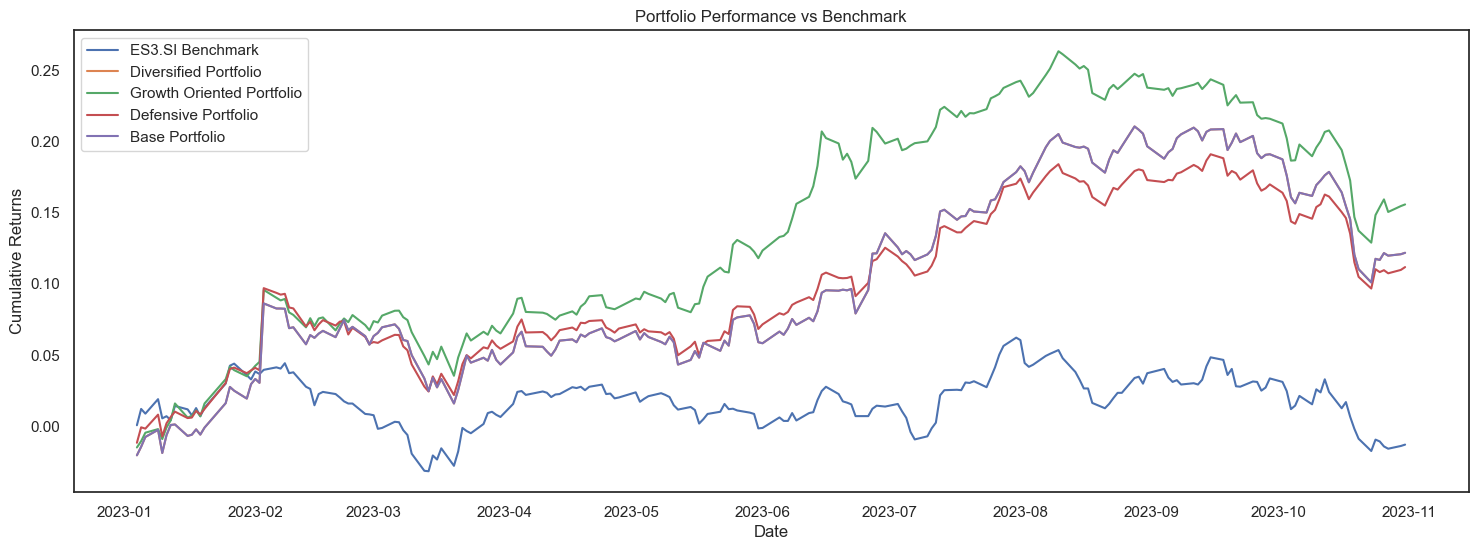

In [129]:
# Prepare benchmark metrics in a dictionary
benchmark_metrics = {
  'annual_regular_return': annual_regular_return_benchmark,
  'annual_std': annual_regular_std_benchmark,
  'sharpe_ratio': sharpe_ratio_benchmark
}

portfolio_comparison_with_benchmark(portfolios_returns, benchmark, benchmark_metrics, backtesting_start, backtesting_end)

Remarks:

Based on the information presented above, we can derive the following insights:

1. **Annual Return vs Risk**
   * The **Growth Oriented Portfolio** has the highest **annual regular return** at **20.89%**, reflecting its aggressive allocation strategy.
   * The **Defensive Portfolio** shows the lowest return (**14.58%**) but also lower volatility (**12.16%**), consistent with a conservative approach.
   * The **Diversified** and **Base Portfolios** have similar returns (**~15.99%**) and volatility (**~13.75%**), suggesting that the Base Portfolio closely mirrors the diversified benchmark allocation.

2. **Sharpe Ratio (Risk-Adjusted Return)**
   * The Growth Oriented Portfolio achieves the **highest Sharpe ratio (1.59)**, indicating it provides the **best return per unit of risk**.
   * The Diversified/Base Portfolio has a Sharpe ratio of **1.16**, slightly lower than the Defensive Portfolio (**1.20**), reflecting moderate risk-adjusted performance.

3. **Information Ratio (Excess Return Relative to Benchmark)**
   * Growth Oriented Portfolio again leads with **0.080**, suggesting it outperforms the benchmark consistently relative to its tracking error.
   * The other portfolios have similar values (~0.062), indicating modest excess returns relative to benchmark variability.

4. **Treynor Ratio (Return per Unit of Systematic Risk)**
   * Growth Oriented Portfolio also has the **highest Treynor ratio (26.84)**, demonstrating superior returns for market-related risk exposure.
   * Defensive Portfolio has the lowest Treynor ratio (17.07), in line with its lower beta-like exposure.

5. **Calmar Ratio (Return Relative to Maximum Drawdown)**
   * All portfolios show **very high Calmar ratios (145–155)**, suggesting that maximum drawdowns were **very small relative to annual returns**, indicating stable performance.
   * The Growth Oriented Portfolio again ranks highest, showing **strong upside performance without extreme drawdowns**.

In summary:

* **Growth Oriented Portfolio**: Best overall performance in terms of returns and risk-adjusted metrics, making it attractive for investors willing to accept moderate volatility.
* **Defensive Portfolio**: Lower return but less volatile, suitable for risk-averse investors.
* **Diversified/Base Portfolio**: Balanced profile with moderate return and risk; a good compromise between growth and stability.

⚡ **Observation:** The Base Portfolio’s metrics exactly match the Diversified Portfolio, indicating that our **Base Portfolio allocation is aligned with the diversified strategy** used for comparison.